In [1]:
# Delivery Time Prediction using Linear Regression

In [2]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
# load dataset
df = pd.read_csv("D:/Goutham/Projects/Python/Project 2/Project  -  Simple Linear Regression/2. Simple Linear Regression/delivery_time.csv")
df.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [4]:
# pre-processing
# Clean column names
df.columns = df.columns.str.replace(" ", "_")

df.head()

,Delivery_Time,Sorting_Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [5]:
# understanding data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery_Time  21 non-null     float64
 1   Sorting_Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes


,Delivery_Time,Sorting_Time
count,21.000000,21.000000
mean,16.790952,6.190476
std,5.074901,2.542028
min,8.000000,2.000000
25%,13.500000,4.000000
50%,17.830000,6.000000
75%,19.750000,8.000000
max,29.000000,10.000000


The dataset contains Sorting_Time (independent variable) and 
Delivery_Time (dependent variable). There are no missing values.

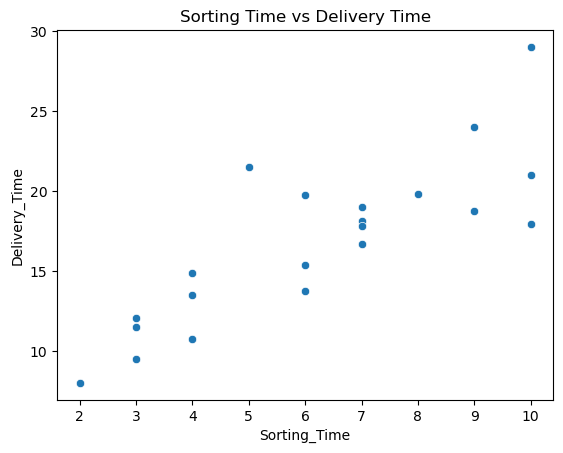

In [7]:
# Performaing EDA
# scatterplot
sns.scatterplot(x='Sorting_Time', y='Delivery_Time', data=df)
plt.title("Sorting Time vs Delivery Time")
plt.show()

There is a positive relationship between sorting time and delivery time.
A slight curvature suggests possible non-linearity.

In [8]:
# Correlation
df.corr()

,Delivery_Time,Sorting_Time
Delivery_Time,1.000000,0.825997
Sorting_Time,0.825997,1.000000


Correlation is approximately 0.82, indicating a strong positive relationship.

In [9]:
# Model building - Linear Regression
X = df[['Sorting_Time']]
y = df['Delivery_Time']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
r2

0.6822714748417231

The linear model gives an R² score of approximately 0.68,
indicating moderate predictive performance.

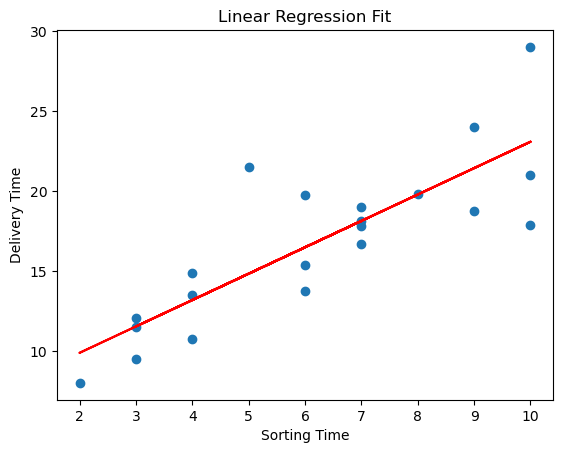

In [10]:
# Regression Line visualization
plt.scatter(df['Sorting_Time'], df['Delivery_Time'])
plt.plot(df['Sorting_Time'], y_pred, color='red')
plt.title("Linear Regression Fit")
plt.xlabel("Sorting Time")
plt.ylabel("Delivery Time")
plt.show()

In [11]:
# Transformations

# log X transformation
X_log = np.log(X)

model_log = LinearRegression()
model_log.fit(X_log, y)

y_pred_log = model_log.predict(X_log)

r2_log = r2_score(y, y_pred_log)
r2_log

0.6954434611324223

In [12]:
# Exponential Model Log y
y_log = np.log(y)

model_exp = LinearRegression()
model_exp.fit(X, y_log)

y_pred_exp = np.exp(model_exp.predict(X))

r2_exp = r2_score(y, y_pred_exp)
r2_exp

0.6475457259313306

In [13]:
# Model comparison
results = pd.DataFrame({
    'Model': ['Linear', 'Log', 'Exponential'],
    'R2': [r2, r2_log, r2_exp]
})

results

,Model,R2
0,Linear,0.682271
1,Log,0.695443
2,Exponential,0.647546


In [14]:
# Predictions
new_data = pd.DataFrame({'Sorting_Time': [5, 10, 15]})

predictions = model_log.predict(np.log(new_data))

predictions

array([15.71449599, 21.98291253, 25.64970115])

In [15]:
# Save output
output = pd.DataFrame({
    'Sorting_Time': [5, 10, 15],
    'Predicted_Delivery_Time': predictions
})

output.to_csv("delivery_predictions.csv", index=False)

Conclusion

The relationship between sorting time and delivery time is positive but slightly non-linear.

The linear model achieved an R² of 0.68, while the log transformation improved it to 0.695.

Thus, the log-transformed model is selected as the best model for predicting delivery time.

Business Insight:
Improving sorting efficiency can significantly reduce delivery time, 
but the relationship is not perfectly linear, indicating diminishing returns at higher sorting times.